🟢 Race Started! Monitoring systems...
🚨 [TIME: 15s] CYBER ATTACK INITIATED: Spoofing Safe Sam's sensors!
💥 [TIME: 19s] CRITICAL FAILURE: Safe Sam lost control at 40.8 m/s and CRASHED!
⚠️ [TIME: 22s] WEATHER: Sudden Rain!
🏁 Race Finished!


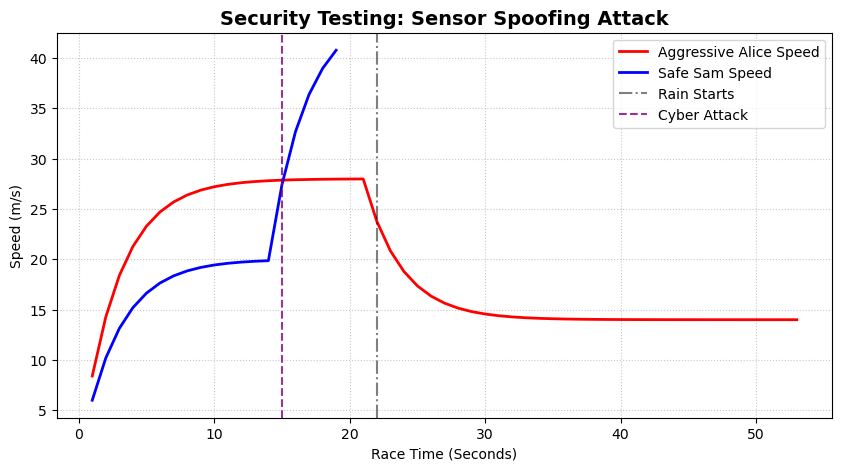

In [11]:
import matplotlib.pyplot as plt

# --- 🏗️ THE VULNERABLE BLUEPRINT (CLASS) ---
class RaceCar:
    def __init__(self, name, strategy):
        self.name = name
        self.strategy = strategy
        self.distance = 0
        self.speed = 0
        self.fuel = 100.0
        
        # Cyber Security States
        self.sensor_spoof_offset = 0  
        self.crashed = False          
        
        self.history = {'time': [], 'speed': [], 'fuel': []}

    def drive(self, current_time, is_raining):
        # Stop driving if finished, out of gas, or crashed
        if self.distance >= 1000 or self.fuel <= 0 or self.crashed:
            return 
            
        if self.strategy == 'aggressive':
            target_speed = 28 if self.fuel > 15 else 12
        else: 
            target_speed = 20 if self.fuel > 10 else 12

        if is_raining:
            target_speed = min(target_speed, 14)

        # 🏴‍☠️ The Vulnerability (Spoofed Perception)
        perceived_speed = self.speed - self.sensor_spoof_offset
        error = target_speed - perceived_speed
        
        # Physics Actuation
        Kp = 0.3
        speed_change = Kp * error
        self.speed += speed_change

        if speed_change > 0:
            self.fuel -= (0.4 * speed_change)
        else:
            self.fuel -= 0.05
            
        self.distance += self.speed

        # # --- 💥 CRASH CONDITION --- OLD VERSION, Dosen't reach the full speed in the graph "40.8 m/s"
        # # If actual physical speed exceeds 40 m/s, the car loses control and crashes.
        # if self.speed > 40:
        #     print(f"💥 [TIME: {current_time}s] CRITICAL FAILURE: {self.name} lost control at {self.speed:.1f} m/s and CRASHED!")
        #     self.crashed = True
        #     self.speed = 0  # Instant stop
        
        # self.history['time'].append(current_time)
        # self.history['speed'].append(self.speed)
        # self.history['fuel'].append(self.fuel)
        
        # --- 💥 CRASH CONDITION (New Version) ---
        if self.speed > 40:
            print(f"💥 [TIME: {current_time}s] CRITICAL FAILURE: {self.name} lost control at {self.speed:.1f} m/s and CRASHED!")
            self.crashed = True
            
            # Log the exact peak crash data FIRST so the graph captures it
            self.history['time'].append(current_time)
            self.history['speed'].append(self.speed)
            self.history['fuel'].append(self.fuel)
            
            # Now safely zero out the speed for the physics engine
            self.speed = 0 
            return # Exit early so we don't log the data a second time
        
        # Standard Data Logging (Only runs if the car didn't crash)
        self.history['time'].append(current_time)
        self.history['speed'].append(self.speed)
        self.history['fuel'].append(self.fuel)

# --- 🏁 THE HACKED RACE TRACK (MAIN LOOP) ---
car1 = RaceCar("Aggressive Alice", "aggressive")
car2 = RaceCar("Safe Sam", "safe")

seconds = 0
rain_triggered = False
rain_time = 0

print("🟢 Race Started! Monitoring systems...")

while (car1.distance < 1000 and car1.fuel > 0 and not car1.crashed) or \
      (car2.distance < 1000 and car2.fuel > 0 and not car2.crashed):
    
    seconds += 1
    
    # 🌧️ Chaos Event: Rain
    if not rain_triggered and (car1.distance >= 500 or car2.distance >= 500):
        rain_triggered = True
        rain_time = seconds
        print(f"⚠️ [TIME: {seconds}s] WEATHER: Sudden Rain!")

    # 🏴‍☠️ Chaos Event: CYBER ATTACK
    if seconds == 15:
        print(f"🚨 [TIME: {seconds}s] CYBER ATTACK INITIATED: Spoofing Safe Sam's sensors!")
        car2.sensor_spoof_offset = 25  # Tell the car it is going 25 m/s slower than reality

    car1.drive(seconds, rain_triggered)
    car2.drive(seconds, rain_triggered)

print("🏁 Race Finished!")

# --- 📈 THE VISUALIZATION ---
plt.figure(figsize=(10, 5))

plt.plot(car1.history['time'], car1.history['speed'], label=f'{car1.name} Speed', color='red', linewidth=2)
plt.plot(car2.history['time'], car2.history['speed'], label=f'{car2.name} Speed', color='blue', linewidth=2)

if rain_time > 0:
    plt.axvline(x=rain_time, color='black', linestyle='-.', alpha=0.5, label='Rain Starts')

# Mark the exact moment of the hack
plt.axvline(x=15, color='purple', linestyle='--', alpha=0.8, label='Cyber Attack')

plt.title("Security Testing: Sensor Spoofing Attack", fontsize=14, fontweight='bold')
plt.xlabel("Race Time (Seconds)")
plt.ylabel("Speed (m/s)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

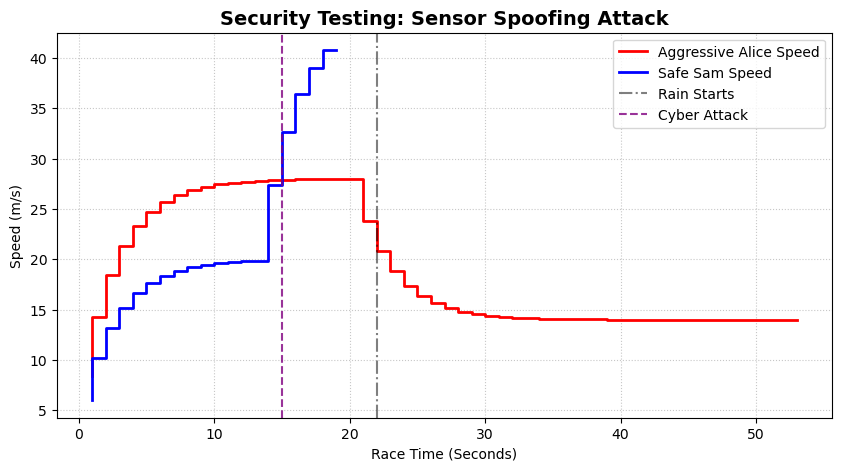

In [12]:
# --- 📈 THE VISUALIZATION ---
plt.figure(figsize=(10, 5))

plt.step(car1.history['time'], car1.history['speed'], label=f'{car1.name} Speed', color='red', linewidth=2)
plt.step(car2.history['time'], car2.history['speed'], label=f'{car2.name} Speed', color='blue', linewidth=2)

if rain_time > 0:
    plt.axvline(x=rain_time, color='black', linestyle='-.', alpha=0.5, label='Rain Starts')

# Mark the exact moment of the hack
plt.axvline(x=15, color='purple', linestyle='--', alpha=0.8, label='Cyber Attack')

plt.title("Security Testing: Sensor Spoofing Attack", fontsize=14, fontweight='bold')
plt.xlabel("Race Time (Seconds)")
plt.ylabel("Speed (m/s)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [13]:
# --- ⛽ FUEL TELEMETRY TABLE ---
def print_fuel_table(car):
    print(f"\n⛽ Fuel Burn Log: {car.name}")
    print("=" * 35)
    print(f"{'Time (Seconds)':<18} | {'Fuel Level':<12}")
    print("-" * 35)
    
    # Loop through the car's history
    for i in range(len(car.history['time'])):
        time_sec = car.history['time'][i]
        fuel_pct = car.history['fuel'][i]
        
        # Pro-Tip: Print every 5 seconds so the terminal doesn't get flooded!
        # (We also make sure to print the very last second of the race)
        if time_sec % 5 == 0 or i == len(car.history['time']) - 1:
            # The :<18 forces the text to be 18 spaces wide for a perfect column
            print(f"{time_sec:<18} | {fuel_pct:.1f}%")
            
    print("=" * 35)

# Generate tables for both cars
print_fuel_table(car1)
print_fuel_table(car2)


⛽ Fuel Burn Log: Aggressive Alice
Time (Seconds)     | Fuel Level  
-----------------------------------
5                  | 90.7%
10                 | 89.1%
15                 | 88.9%
20                 | 88.8%
25                 | 88.6%
30                 | 88.4%
35                 | 88.1%
40                 | 87.9%
45                 | 87.6%
50                 | 87.4%
53                 | 87.2%

⛽ Fuel Burn Log: Safe Sam
Time (Seconds)     | Fuel Level  
-----------------------------------
5                  | 93.3%
10                 | 92.2%
15                 | 89.0%
19                 | 83.7%
